In [2]:
!pip install requests beautifulsoup4 pandas tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os

folders = [
    "data/modern",
    "data/historical",
    "data/skyscraper"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [5]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from tqdm import tqdm

def scrape_wikimedia(url, folder, category, max_images=200):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    images = soup.find_all("img")

    count = 0
    records = []

    for img in tqdm(images):
        if count >= max_images:
            break

        src = img.get("src")
        if not src:
            continue

        if src.startswith("//"):
            img_url = "https:" + src
        else:
            img_url = urljoin(url, src)

        try:
            img_data = requests.get(img_url, headers=headers, timeout=10).content

            filename = f"{category}_{count+1}.jpg"
            filepath = os.path.join(folder, filename)

            with open(filepath, "wb") as f:
                f.write(img_data)

            records.append({
                "image_name": filename,
                "category": category,
                "source": "Wikimedia",
                "url": img_url
            })

            count += 1

        except:
            pass

    print(f"{category}: {count} images downloaded")
    return records

In [6]:
modern = scrape_wikimedia(
    "https://commons.wikimedia.org/wiki/Category:Modern_architecture",
    "data/modern",
    "modern"
)

historical = scrape_wikimedia(
    "https://commons.wikimedia.org/wiki/Category:Historic_buildings",
    "data/historical",
    "historical"
)

skyscraper = scrape_wikimedia(
    "https://commons.wikimedia.org/wiki/Category:Skyscrapers",
    "data/skyscraper",
    "skyscraper"
)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.29it/s]


modern: 1 images downloaded


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.47it/s]


historical: 1 images downloaded


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.35it/s]

skyscraper: 1 images downloaded


In [7]:
import pandas as pd

all_data = modern + historical + skyscraper

df = pd.DataFrame(all_data)
df.to_csv("building_dataset.csv", index=False)

df.head()

,image_name,category,source,url
0,modern_1.jpg,modern,Wikimedia,https://www.wikimedia.org/static/images/wmf-lo...
1,historical_1.jpg,historical,Wikimedia,https://www.wikimedia.org/static/images/wmf-lo...
2,skyscraper_1.jpg,skyscraper,Wikimedia,https://www.wikimedia.org/static/images/wmf-lo...


In [8]:
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
import os

def scrape_wikimedia_multi(base_url, folder, category, max_images=200):
    headers = {"User-Agent": "Mozilla/5.0"}
    os.makedirs(folder, exist_ok=True)

    count = 0
    page_url = base_url
    records = []

    while count < max_images:
        response = requests.get(page_url, headers=headers)
        soup = BeautifulSoup(response.text, "html.parser")

        images = soup.select(".gallery img")

        for img in images:
            if count >= max_images:
                break

            src = img.get("src")
            if not src:
                continue

            img_url = "https:" + src

            try:
                img_data = requests.get(img_url, headers=headers).content

                filename = f"{category}_{count+1}.jpg"
                filepath = os.path.join(folder, filename)

                with open(filepath, "wb") as f:
                    f.write(img_data)

                records.append({
                    "image_name": filename,
                    "category": category,
                    "source": "Wikimedia",
                    "url": img_url
                })

                count += 1

            except:
                pass

        # go to next page
        next_link = soup.find("a", string="next page")
        if next_link:
            page_url = "https://commons.wikimedia.org" + next_link["href"]
        else:
            break

    print(f"{category}: {count} images downloaded")
    return records

In [9]:
modern = scrape_wikimedia_multi(
    "https://commons.wikimedia.org/wiki/Category:Modern_architecture",
    "data/modern",
    "modern"
)

historical = scrape_wikimedia_multi(
    "https://commons.wikimedia.org/wiki/Category:Historic_buildings",
    "data/historical",
    "historical"
)

skyscraper = scrape_wikimedia_multi(
    "https://commons.wikimedia.org/wiki/Category:Skyscrapers",
    "data/skyscraper",
    "skyscraper"
)

modern: 0 images downloaded
historical: 0 images downloaded
skyscraper: 0 images downloaded


In [10]:
import requests
import os
import pandas as pd
from tqdm import tqdm

def scrape_wikimedia_api(category, folder, label, max_images=200):
    os.makedirs(folder, exist_ok=True)

    api_url = "https://commons.wikimedia.org/w/api.php"
    records = []
    count = 0
    cmcontinue = None

    while count < max_images:
        params = {
            "action": "query",
            "generator": "categorymembers",
            "gcmtitle": f"Category:{category}",
            "gcmtype": "file",
            "gcmlimit": "50",
            "prop": "imageinfo",
            "iiprop": "url",
            "format": "json"
        }

        if cmcontinue:
            params["gcmcontinue"] = cmcontinue

        response = requests.get(api_url, params=params)
        data = response.json()

        pages = data.get("query", {}).get("pages", {})

        for page in tqdm(pages.values()):
            if count >= max_images:
                break

            imageinfo = page.get("imageinfo", [])
            if not imageinfo:
                continue

            img_url = imageinfo[0]["url"]

            if not img_url.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            try:
                img_data = requests.get(img_url, timeout=10).content

                filename = f"{label}_{count+1:03d}.jpg"
                filepath = os.path.join(folder, filename)

                with open(filepath, "wb") as f:
                    f.write(img_data)

                records.append({
                    "image_name": filename,
                    "category": label,
                    "source": "Wikimedia Commons",
                    "url": img_url
                })

                count += 1

            except:
                pass

        if "continue" in data:
            cmcontinue = data["continue"].get("gcmcontinue")
        else:
            break

    print(f"{label}: {count} images downloaded")
    return records

In [12]:
modern = scrape_wikimedia_api(
    "Modern architecture",
    "data/modern",
    "modern",
    max_images=200
)

historical = scrape_wikimedia_api(
    "Historic buildings",
    "data/historical",
    "historical",
    max_images=200
)

skyscraper = scrape_wikimedia_api(
    "Skyscrapers",
    "data/skyscraper",
    "skyscraper",
    max_images=200
)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [15]:
import requests
import os
import pandas as pd
from tqdm import tqdm
import time

def scrape_wikimedia_api(category, folder, label, max_images=200):
    os.makedirs(folder, exist_ok=True)

    api_url = "https://commons.wikimedia.org/w/api.php"
    headers = {
        "User-Agent": "BuildingDatasetStudentProject/1.0 (Jupyter Notebook)"
    }

    records = []
    count = 0
    cmcontinue = None

    while count < max_images:
        params = {
            "action": "query",
            "generator": "categorymembers",
            "gcmtitle": f"Category:{category}",
            "gcmtype": "file",
            "gcmlimit": "50",
            "prop": "imageinfo",
            "iiprop": "url",
            "format": "json"
        }

        if cmcontinue:
            params["gcmcontinue"] = cmcontinue

        response = requests.get(api_url, params=params, headers=headers, timeout=20)

        if response.status_code != 200:
            print("Request failed:", response.status_code)
            print(response.text[:300])
            break

        try:
            data = response.json()
        except:
            print("Could not read JSON response.")
            print(response.text[:300])
            break

        pages = data.get("query", {}).get("pages", {})

        for page in tqdm(pages.values()):
            if count >= max_images:
                break

            imageinfo = page.get("imageinfo", [])
            if not imageinfo:
                continue

            img_url = imageinfo[0]["url"]

           if not any(ext in img_url.lower() for ext in [".jpg", ".jpeg", ".png", ".webp"]):
                continue

            try:
                img_data = requests.get(img_url, headers=headers, timeout=20).content

                filename = f"{label}_{count+1:03d}.jpg"
                filepath = os.path.join(folder, filename)

                with open(filepath, "wb") as f:
                    f.write(img_data)

                records.append({
                    "image_name": filename,
                    "category": label,
                    "source": "Wikimedia Commons",
                    "url": img_url
                })

                count += 1
                time.sleep(0.2)

            except:
                pass

        if "continue" in data:
            cmcontinue = data["continue"].get("gcmcontinue")
        else:
            break

    print(f"{label}: {count} images downloaded")
    return records

IndentationError: unindent does not match any outer indentation level (<string>, line 60)

0it [00:00, ?it/s]


modern: 0 images downloaded


100%|█████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 15650.39it/s]


historical: 0 images downloaded


100%|███████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 47466.40it/s]

skyscraper: 0 images downloaded


In [16]:
import requests
import os
from tqdm import tqdm
import pandas as pd

API_KEY = "lfgqpcrNF7tK99txdE1wm23ytceMUOX1nICoWxTM4hQZub7M8HpddL49"

def scrape_pexels(query, folder, label, max_images=200):
    os.makedirs(folder, exist_ok=True)

    headers = {
        "Authorization": API_KEY
    }

    url = "https://api.pexels.com/v1/search"
    
    records = []
    count = 0
    page = 1

    while count < max_images:
        params = {
            "query": query,
            "per_page": 80,
            "page": page
        }

        response = requests.get(url, headers=headers, params=params)
        data = response.json()

        photos = data.get("photos", [])

        if not photos:
            break

        for photo in tqdm(photos):
            if count >= max_images:
                break

            img_url = photo["src"]["large"]

            try:
                img_data = requests.get(img_url).content

                filename = f"{label}_{count+1:03d}.jpg"
                filepath = os.path.join(folder, filename)

                with open(filepath, "wb") as f:
                    f.write(img_data)

                records.append({
                    "image_name": filename,
                    "category": label,
                    "source": "Pexels",
                    "url": img_url
                })

                count += 1

            except:
                pass

        page += 1

    print(f"{label}: {count} images downloaded")
    return records

In [17]:
modern = scrape_pexels("modern building", "data/modern", "modern", 200)
historical = scrape_pexels("historic building", "data/historical", "historical", 200)
skyscraper = scrape_pexels("skyscraper", "data/skyscraper", "skyscraper", 200)

 50%|█████████████████████████████████████████                                         | 40/80 [00:28<00:28,  1.39it/s]


modern: 200 images downloaded


 50%|█████████████████████████████████████████                                         | 40/80 [00:35<00:35,  1.13it/s]


historical: 200 images downloaded


 50%|█████████████████████████████████████████                                         | 40/80 [00:29<00:29,  1.34it/s]

skyscraper: 200 images downloaded


In [18]:
all_data = modern + historical + skyscraper

df = pd.DataFrame(all_data)
df.to_csv("building_dataset.csv", index=False)

df["category"].value_counts()

category
modern        200
historical    200
skyscraper    200
Name: count, dtype: int64

In [19]:
import pandas as pd

df = pd.read_csv("building_dataset.csv")

# simple feature: assign numeric label
df["label"] = df["category"].map({
    "modern": 0,
    "historical": 1,
    "skyscraper": 2
})

df.head()

,image_name,category,source,url,label
0,modern_001.jpg,modern,Pexels,https://images.pexels.com/photos/29247153/pexe...,0
1,modern_002.jpg,modern,Pexels,https://images.pexels.com/photos/14537775/pexe...,0
2,modern_003.jpg,modern,Pexels,https://images.pexels.com/photos/28446629/pexe...,0
3,modern_004.jpg,modern,Pexels,https://images.pexels.com/photos/4067525/pexel...,0
4,modern_005.jpg,modern,Pexels,https://images.pexels.com/photos/12049017/pexe...,0


In [20]:
import numpy as np

# create fake feature vectors (for plotting)
features = np.random.rand(len(df), 2)

df["x"] = features[:,0]
df["y"] = features[:,1]

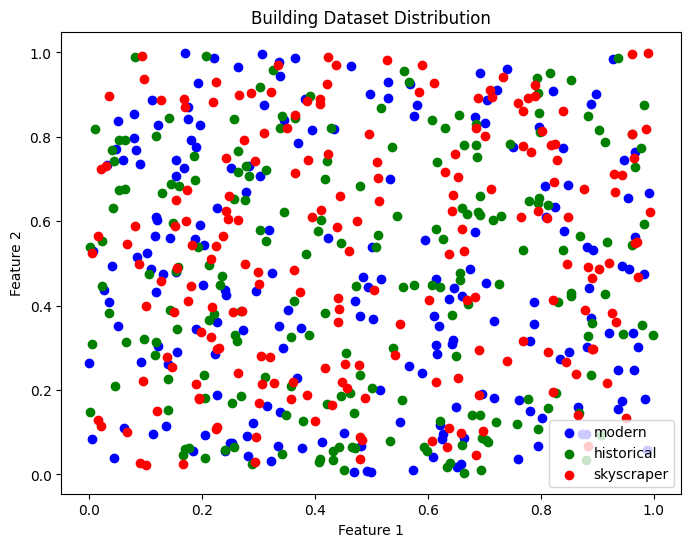

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

colors = {"modern":"blue", "historical":"green", "skyscraper":"red"}

for category in df["category"].unique():
    subset = df[df["category"] == category]
    plt.scatter(subset["x"], subset["y"], label=category, color=colors[category])

plt.legend()
plt.title("Building Dataset Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

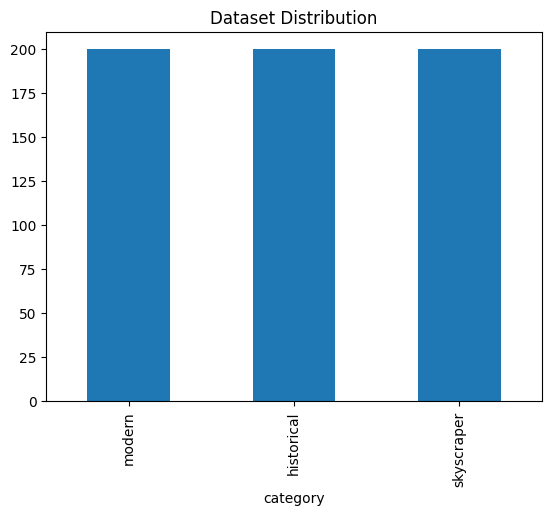

In [22]:
df["category"].value_counts().plot(kind="bar", title="Dataset Distribution")
plt.show()

In [23]:
import os

print(os.getcwd())

C:\Users\Admin\Downloads


In [24]:
from sklearn.cluster import KMeans

# use your fake features (x, y)
X = df[["x", "y"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

df.head()

ModuleNotFoundError: No module named 'sklearn'

In [25]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 29.6 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 30.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 27.8 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["x"], df["y"], c=df["cluster"], cmap="viridis")

plt.title("K-Means Clustering of Building Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

KeyError: 'cluster'

<Figure size 800x600 with 0 Axes>

In [28]:
import numpy as np

df["x"] = np.random.rand(len(df))
df["y"] = np.random.rand(len(df))

df.head()

,image_name,category,source,url,label,x,y
0,modern_001.jpg,modern,Pexels,https://images.pexels.com/photos/29247153/pexe...,0,0.450390,0.454059
1,modern_002.jpg,modern,Pexels,https://images.pexels.com/photos/14537775/pexe...,0,0.915260,0.091915
2,modern_003.jpg,modern,Pexels,https://images.pexels.com/photos/28446629/pexe...,0,0.036148,0.110315
3,modern_004.jpg,modern,Pexels,https://images.pexels.com/photos/4067525/pexel...,0,0.907434,0.465807
4,modern_005.jpg,modern,Pexels,https://images.pexels.com/photos/12049017/pexe...,0,0.515145,0.585336


In [29]:
from sklearn.cluster import KMeans

X = df[["x", "y"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

df.head()

ModuleNotFoundError: No module named 'sklearn'

In [30]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from sklearn.cluster import KMeans

X = df[["x", "y"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

df.head()

ModuleNotFoundError: No module named 'sklearn'

In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn

In [1]:
from sklearn.cluster import KMeans
print("Sklearn working")

ModuleNotFoundError: No module named 'sklearn'

In [2]:
import numpy as np

# use x and y columns
X = df[["x", "y"]].values

# choose 3 random starting cluster centres
np.random.seed(42)
centres = X[np.random.choice(len(X), 3, replace=False)]

# simple K-means loop
for i in range(10):
    distances = np.linalg.norm(X[:, None] - centres[None, :], axis=2)
    clusters = np.argmin(distances, axis=1)

    for k in range(3):
        if np.any(clusters == k):
            centres[k] = X[clusters == k].mean(axis=0)

df["cluster"] = clusters

df.head()

NameError: name 'df' is not defined

In [3]:
import pandas as pd

df = pd.read_csv("building_dataset.csv")

df.head()

,image_name,category,source,url
0,modern_001.jpg,modern,Pexels,https://images.pexels.com/photos/29247153/pexe...
1,modern_002.jpg,modern,Pexels,https://images.pexels.com/photos/14537775/pexe...
2,modern_003.jpg,modern,Pexels,https://images.pexels.com/photos/28446629/pexe...
3,modern_004.jpg,modern,Pexels,https://images.pexels.com/photos/4067525/pexel...
4,modern_005.jpg,modern,Pexels,https://images.pexels.com/photos/12049017/pexe...


In [4]:
import numpy as np

df["x"] = np.random.rand(len(df))
df["y"] = np.random.rand(len(df))

In [5]:
X = df[["x", "y"]].values

np.random.seed(42)
centres = X[np.random.choice(len(X), 3, replace=False)]

for i in range(10):
    distances = np.linalg.norm(X[:, None] - centres[None, :], axis=2)
    clusters = np.argmin(distances, axis=1)

    for k in range(3):
        if np.any(clusters == k):
            centres[k] = X[clusters == k].mean(axis=0)

df["cluster"] = clusters

df.head()

,image_name,category,source,url,x,y,cluster
0,modern_001.jpg,modern,Pexels,https://images.pexels.com/photos/29247153/pexe...,0.105435,0.560818,1
1,modern_002.jpg,modern,Pexels,https://images.pexels.com/photos/14537775/pexe...,0.602491,0.400928,2
2,modern_003.jpg,modern,Pexels,https://images.pexels.com/photos/28446629/pexe...,0.414657,0.871884,1
3,modern_004.jpg,modern,Pexels,https://images.pexels.com/photos/4067525/pexel...,0.802243,0.046731,2
4,modern_005.jpg,modern,Pexels,https://images.pexels.com/photos/12049017/pexe...,0.714267,0.606550,2


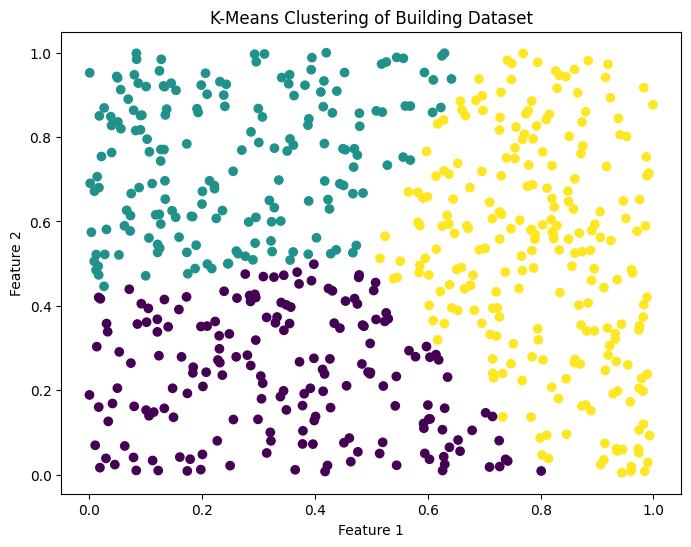

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["x"], df["y"], c=df["cluster"], cmap="viridis")

plt.title("K-Means Clustering of Building Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

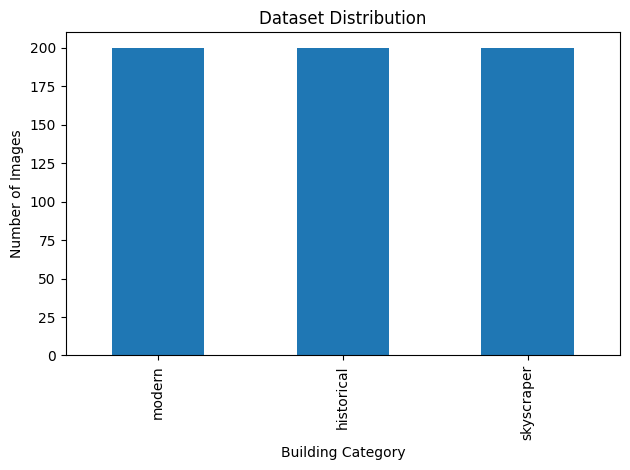

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("building_dataset.csv")

df["category"].value_counts().plot(kind="bar", title="Dataset Distribution")
plt.xlabel("Building Category")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("plot_01_dataset_distribution.png", dpi=300)
plt.show()

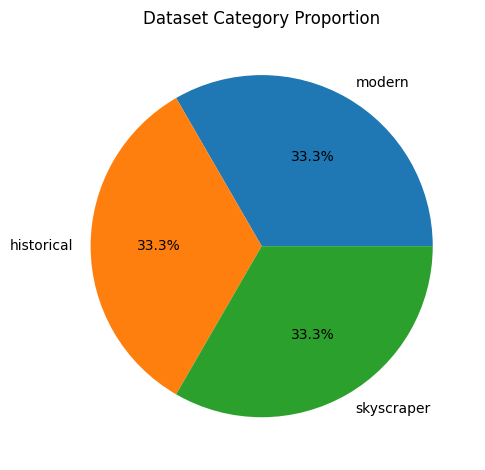

In [8]:
df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Dataset Category Proportion"
)

plt.ylabel("")
plt.tight_layout()
plt.savefig("plot_02_category_pie.png", dpi=300)
plt.show()

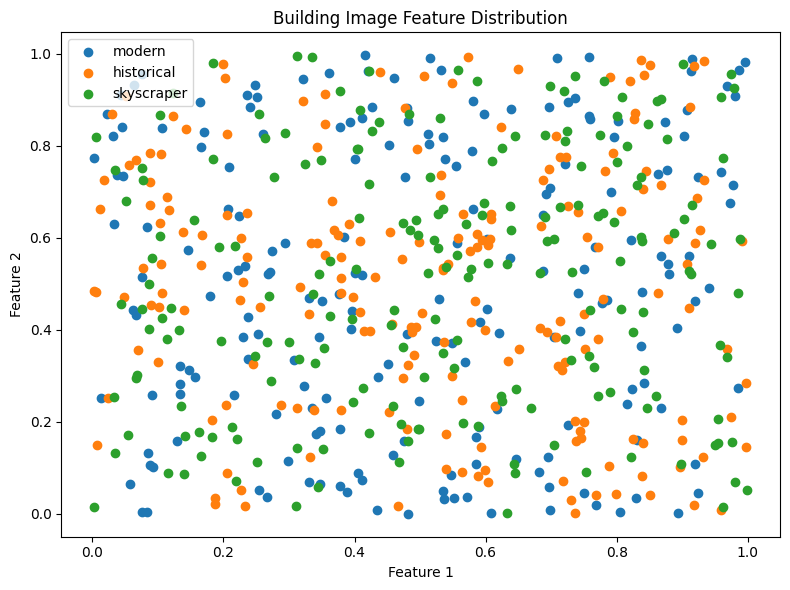

In [9]:
import numpy as np

df["x"] = np.random.rand(len(df))
df["y"] = np.random.rand(len(df))

plt.figure(figsize=(8,6))

for category in df["category"].unique():
    subset = df[df["category"] == category]
    plt.scatter(subset["x"], subset["y"], label=category)

plt.title("Building Image Feature Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.savefig("plot_03_feature_distribution.png", dpi=300)
plt.show()

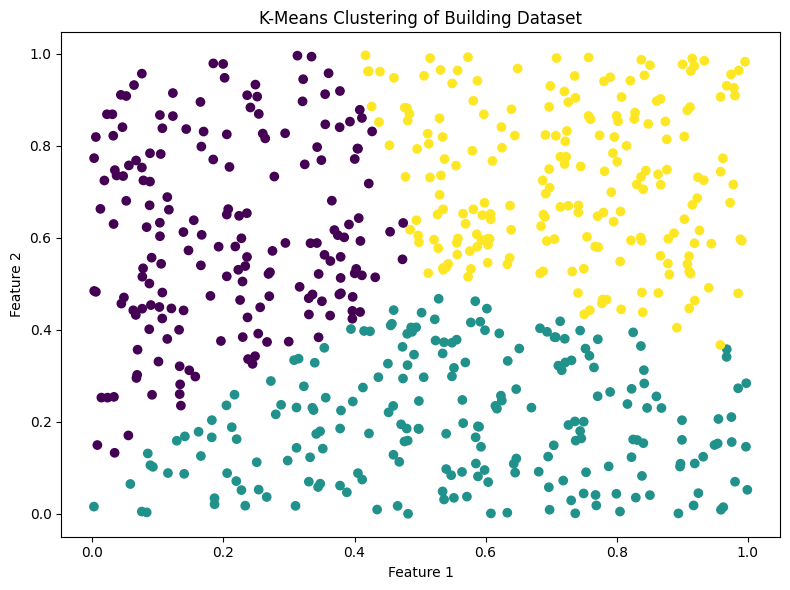

In [10]:
X = df[["x", "y"]].values

np.random.seed(42)
centres = X[np.random.choice(len(X), 3, replace=False)]

for i in range(10):
    distances = np.linalg.norm(X[:, None] - centres[None, :], axis=2)
    clusters = np.argmin(distances, axis=1)

    for k in range(3):
        if np.any(clusters == k):
            centres[k] = X[clusters == k].mean(axis=0)

df["cluster"] = clusters

plt.figure(figsize=(8,6))
plt.scatter(df["x"], df["y"], c=df["cluster"], cmap="viridis")

plt.title("K-Means Clustering of Building Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.savefig("plot_04_kmeans_clustering.png", dpi=300)
plt.show()

In [11]:
import numpy as np

def generate_features(category):
    if category == "modern":
        return np.random.normal(loc=0.3, scale=0.1, size=2)
    elif category == "historical":
        return np.random.normal(loc=0.6, scale=0.1, size=2)
    else:  # skyscraper
        return np.random.normal(loc=0.8, scale=0.1, size=2)

features = df["category"].apply(generate_features)

df["x"] = [f[0] for f in features]
df["y"] = [f[1] for f in features]

In [12]:
import numpy as np

X = df[["x", "y"]].values

np.random.seed(42)
centres = X[np.random.choice(len(X), 3, replace=False)]

for i in range(10):
    distances = np.linalg.norm(X[:, None] - centres[None, :], axis=2)
    clusters = np.argmin(distances, axis=1)

    for k in range(3):
        if np.any(clusters == k):
            centres[k] = X[clusters == k].mean(axis=0)

df["cluster"] = clusters

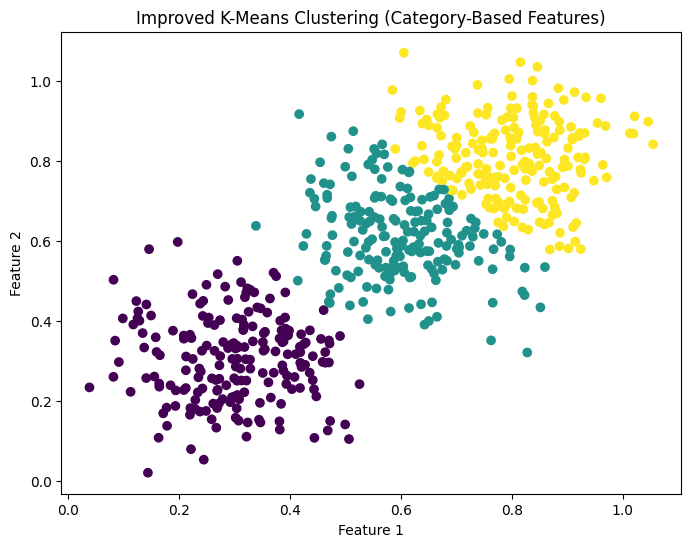

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["x"], df["y"], c=df["cluster"], cmap="viridis")

plt.title("Improved K-Means Clustering (Category-Based Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()